In [2]:
# ============================================================
# Task 2: Image Deblurring with NAFNet
# COMP6001 Assignment 1
# ============================================================

import time, warnings, subprocess
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ── 1. Paths ─────────────────────────────────────────────────
BLUR_DIR   = Path("/kaggle/input/datasets/jishnuparayilshibu/a-curated-list-of-image-deblurring-datasets/DBlur/Gopro/test/blur")
SHARP_DIR  = Path("/kaggle/input/datasets/jishnuparayilshibu/a-curated-list-of-image-deblurring-datasets/DBlur/Gopro/test/sharp")
OUTPUT_DIR = Path("/kaggle/working/outputs/task2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_SAMPLES = 10


# ── 2. NAFNet ─────────────────────────────────────────────────

class LayerNorm2d(nn.LayerNorm):
    def forward(self, x):
        return super().forward(x.permute(0,2,3,1)).permute(0,3,1,2)

class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class NAFBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.norm1 = LayerNorm2d(c)
        self.norm2 = LayerNorm2d(c)
        self.conv1 = nn.Conv2d(c, c*2, 1)
        self.conv2 = nn.Conv2d(c*2, c*2, 3, 1, 1, groups=c*2)
        self.conv3 = nn.Conv2d(c, c, 1)
        self.sca   = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(c, c, 1))
        self.sg    = SimpleGate()
        self.conv4 = nn.Conv2d(c, c*2, 1)
        self.conv5 = nn.Conv2d(c, c, 1)
        self.beta  = nn.Parameter(torch.ones(1, c, 1, 1))
        self.gamma = nn.Parameter(torch.ones(1, c, 1, 1))

    def forward(self, inp):
        x = self.sg(self.conv2(self.conv1(self.norm1(inp))))
        y = inp + self.conv3(x * self.sca(x)) * self.beta
        return y + self.conv5(self.sg(self.conv4(self.norm2(y)))) * self.gamma

class NAFNet(nn.Module):
    def __init__(self, width=64, enc_blks=[2,2,4,8], middle_blk_num=12, dec_blks=[2,2,2,2]):
        super().__init__()
        self.intro       = nn.Conv2d(3, width, 3, 1, 1)
        self.ending      = nn.Conv2d(width, 3, 3, 1, 1)
        self.encoders    = nn.ModuleList()
        self.downs       = nn.ModuleList()
        self.middle_blks = nn.ModuleList()
        self.ups         = nn.ModuleList()
        self.decoders    = nn.ModuleList()

        chan = width
        for n in enc_blks:
            self.encoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
            self.downs.append(nn.Conv2d(chan, chan*2, 2, 2))
            chan *= 2

        self.middle_blks = nn.Sequential(*[NAFBlock(chan) for _ in range(middle_blk_num)])

        for n in dec_blks:
            self.ups.append(nn.Sequential(nn.Conv2d(chan, chan*2, 1, bias=False), nn.PixelShuffle(2)))
            chan //= 2
            self.decoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))

        self.padder_size = 2 ** len(self.encoders)

    def forward(self, inp):
        B, C, H, W = inp.shape
        ph = (self.padder_size - H % self.padder_size) % self.padder_size
        pw = (self.padder_size - W % self.padder_size) % self.padder_size
        x  = F.pad(inp, (0, pw, 0, ph), mode='reflect')
        x  = self.intro(x)
        encs = []
        for enc, down in zip(self.encoders, self.downs):
            x = enc(x); encs.append(x); x = down(x)
        x = self.middle_blks(x)
        for dec, up, skip in zip(self.decoders, self.ups, reversed(encs)):
            x = dec(up(x) + skip)
        return (self.ending(x) + inp)[:, :, :H, :W]


# ── 3. Load weights ───────────────────────────────────────────

def load_nafnet():
    path = Path("./weights/NAFNet-GoPro-width64.pth")
    path.parent.mkdir(exist_ok=True)

    if path.exists() and path.stat().st_size < 10 * 1024 * 1024:
        path.unlink()
        print("Removed corrupted weights file.")

    if not path.exists():
        print("Downloading NAFNet weights from Google Drive (~140 MB)…")
        subprocess.run(["pip", "install", "gdown", "-q"], check=True)
        import gdown
        gdown.download(
            id="14D4V4raNYIOhETfcuuLI3bGLB-OYIv6X",
            output=str(path),
            quiet=False
        )
        print("Download complete.")

    ckpt  = torch.load(path, map_location=device)
    state = ckpt.get("params_ema") or ckpt.get("params") or ckpt

    width      = state["intro.weight"].shape[0]
    num_stages = len({k.split(".")[1] for k in state if k.startswith("downs.")})
    def nblocks(prefix):
        idxs = {int(k[len(prefix):].split(".")[0]) for k in state
                if k.startswith(prefix) and k[len(prefix):].split(".")[0].isdigit()}
        return max(idxs) + 1 if idxs else 0
    enc_blks       = [nblocks(f"encoders.{i}.") for i in range(num_stages)]
    dec_blks       = [nblocks(f"decoders.{i}.") for i in range(num_stages)]
    middle_blk_num = nblocks("middle_blks.")

    model = NAFNet(width=width, enc_blks=enc_blks,
                   middle_blk_num=middle_blk_num, dec_blks=dec_blks)
    model_keys = set(model.state_dict().keys())
    model.load_state_dict({k: v for k, v in state.items() if k in model_keys}, strict=False)
    return model.eval().to(device)


# ── 4. Dataset ────────────────────────────────────────────────

class GoproDataset(Dataset):
    EXTS = {".png", ".jpg", ".jpeg", ".bmp"}

    def __init__(self, blur_dir, sharp_dir, max_samples=None):
        blur_dir, sharp_dir = Path(blur_dir), Path(sharp_dir)
        sharp_lookup = {
            p.relative_to(sharp_dir): p
            for p in sharp_dir.rglob("*") if p.suffix.lower() in self.EXTS
        }
        self.pairs = [
            (bp, sharp_lookup[bp.relative_to(blur_dir)])
            for bp in sorted(blur_dir.rglob("*"))
            if bp.suffix.lower() in self.EXTS and bp.relative_to(blur_dir) in sharp_lookup
        ]
        if not self.pairs:
            raise RuntimeError("No matched blur/sharp pairs found.")
        if max_samples:
            self.pairs = self.pairs[:max_samples]
        print(f"Dataset: {len(self.pairs)} pairs")

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        bp, sp = self.pairs[idx]
        def read(p):
            img = cv2.imread(str(p), cv2.IMREAD_COLOR)
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        sharp = read(sp)
        blur  = cv2.resize(read(bp), (sharp.shape[1], sharp.shape[0]), interpolation=cv2.INTER_AREA)
        t = lambda x: torch.from_numpy(x.transpose(2, 0, 1))
        return {"blur": t(blur), "sharp": t(sharp)}


# ── 5. Metrics ────────────────────────────────────────────────

def compute_metrics(pred, target):
    psnr = psnr_fn(target, pred, data_range=1.0)
    ssim = ssim_fn(target, pred, data_range=1.0, channel_axis=2)
    return psnr, ssim


# ── 6. Plots ──────────────────────────────────────────────────

def save_comparison(blur, sharp, deblurred, idx, save_dir, psnr_b, ssim_b, psnr_d, ssim_d):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor("#111827")
    for ax, img, title in zip(axes,
        [blur, deblurred, sharp],
        [f"Blurred\nPSNR={psnr_b:.2f} dB  SSIM={ssim_b:.4f}",
         f"NAFNet Output\nPSNR={psnr_d:.2f} dB  SSIM={ssim_d:.4f}",
         "Sharp (Ground Truth)"]
    ):
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(title, color="white", fontsize=10)
        ax.axis("off")
    plt.tight_layout(pad=1.5)
    plt.savefig(save_dir / f"comparison_{idx:04d}.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)

def save_metric_plot(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("NAFNet — PSNR & SSIM", fontsize=13, fontweight="bold")
    for ax, bk, dk, label in zip(axes,
        ["psnr_blur", "ssim_blur"],
        ["psnr_deblurred", "ssim_deblurred"],
        ["PSNR (dB)", "SSIM"]
    ):
        b, d, x = [r[bk] for r in results], [r[dk] for r in results], np.arange(len(results))
        ax.plot(x, b, color="#6c88d4", label="Blurred")
        ax.plot(x, d, color="#e88b3a", label="Deblurred")
        ax.fill_between(x, b, d, where=[dv>=bv for dv,bv in zip(d,b)], alpha=0.15, color="#e88b3a")
        ax.set_ylabel(label); ax.set_xlabel("Image index")
        ax.legend(); ax.grid(linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "metric_summary.png", dpi=150, bbox_inches="tight")
    plt.close(fig)


# ── 7. Main ───────────────────────────────────────────────────

def run_task2(max_samples=MAX_SAMPLES, visualise_every=2):
    loader  = DataLoader(GoproDataset(BLUR_DIR, SHARP_DIR, max_samples),
                         batch_size=1, shuffle=False, num_workers=2)
    model   = load_nafnet()
    vis_dir = OUTPUT_DIR / "comparisons"
    vis_dir.mkdir(exist_ok=True)
    results = []

    for i, batch in enumerate(tqdm(loader, desc="Deblurring")):
        blur_t, sharp_t = batch["blur"][0], batch["sharp"][0]

        t0 = time.perf_counter()
        with torch.inference_mode():
            deblu_t = model(blur_t.unsqueeze(0).to(device)).clamp(0,1)[0].cpu()
        elapsed = time.perf_counter() - t0

        np3     = lambda t: t.numpy().transpose(1,2,0)
        blur_np = np3(blur_t)
        shp_np  = np3(sharp_t)
        deb_np  = np3(deblu_t)

        psnr_b, ssim_b = compute_metrics(blur_np, shp_np)
        psnr_d, ssim_d = compute_metrics(deb_np,  shp_np)

        results.append({
            "idx":            i,
            "psnr_blur":      psnr_b, "psnr_deblurred": psnr_d,
            "ssim_blur":      ssim_b, "ssim_deblurred": ssim_d,
            "psnr_gain":      psnr_d - psnr_b,
            "ssim_gain":      ssim_d - ssim_b,
            "latency_s":      elapsed,
        })

        if i % visualise_every == 0:
            save_comparison(blur_np, shp_np, deb_np, i, vis_dir,
                            psnr_b, ssim_b, psnr_d, ssim_d)

        cv2.imwrite(str(OUTPUT_DIR / f"deblurred_{i:04d}.png"),
                    cv2.cvtColor((deb_np*255).astype(np.uint8), cv2.COLOR_RGB2BGR))

    n   = len(results)
    avg = lambda k: sum(r[k] for r in results) / n

    print(f"\n{'='*57}")
    print(f"  NAFNet Results — {n} images")
    print(f"{'='*57}")
    print(f"  {'Metric':<24}  {'Blurred':>10}  {'Deblurred':>10}  {'Gain':>8}")
    print(f"  {'-'*53}")
    print(f"  {'PSNR (dB)':<24}  {avg('psnr_blur'):>10.4f}  {avg('psnr_deblurred'):>10.4f}  {avg('psnr_gain'):>+8.4f}")
    print(f"  {'SSIM':<24}  {avg('ssim_blur'):>10.4f}  {avg('ssim_deblurred'):>10.4f}  {avg('ssim_gain'):>+8.4f}")
    print(f"  {'Avg latency (s)':<24}  {avg('latency_s'):>10.4f}")
    print(f"{'='*57}\n")
    print(f"  {'idx':>4}  {'PSNR_blur':>9}  {'PSNR_deblu':>10}  {'SSIM_blur':>9}  {'SSIM_deblu':>10}")
    for r in results:
        print(f"  {r['idx']:>4}  {r['psnr_blur']:>9.3f}  {r['psnr_deblurred']:>10.3f}"
              f"  {r['ssim_blur']:>9.4f}  {r['ssim_deblurred']:>10.4f}")

    save_metric_plot(results)
    return results


results = run_task2()

Using device: cuda
Dataset: 10 pairs


Downloading...
From (original): https://drive.google.com/uc?id=14D4V4raNYIOhETfcuuLI3bGLB-OYIv6X
From (redirected): https://drive.google.com/uc?id=14D4V4raNYIOhETfcuuLI3bGLB-OYIv6X&confirm=t&uuid=eb069098-ac16-456f-a36e-9a5ff0459c9c
To: /kaggle/working/weights/NAFNet-GoPro-width64.pth
100%|██████████| 272M/272M [00:02<00:00, 127MB/s] 


Download complete.


Deblurring: 100%|██████████| 10/10 [00:21<00:00,  2.14s/it]



  NAFNet Results — 10 images
  Metric                       Blurred   Deblurred      Gain
  -----------------------------------------------------
  PSNR (dB)                    26.4127     29.3281   +2.9154
  SSIM                          0.8625      0.9137   +0.0512
  Avg latency (s)               1.1686

   idx  PSNR_blur  PSNR_deblu  SSIM_blur  SSIM_deblu
     0     20.362      25.502     0.7194      0.8553
     1     22.015      28.300     0.7552      0.9018
     2     24.300      28.831     0.8334      0.9174
     3     26.827      29.265     0.8264      0.8756
     4     25.516      29.008     0.8373      0.9102
     5     31.035      31.700     0.9565      0.9491
     6     27.896      29.832     0.9142      0.9283
     7     28.049      29.853     0.9169      0.9282
     8     28.591      30.190     0.9234      0.9301
     9     29.536      30.801     0.9419      0.9408


In [5]:
# ============================================================
# Task 3: Object Detection and Analysis
# COMP6001 Assignment 1
# ============================================================

import subprocess
subprocess.run(["pip", "install", "ultralytics", "-q"], check=True)

import time, warnings
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ultralytics import YOLO
from tqdm import tqdm

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ── 1. Paths ─────────────────────────────────────────────────
BLUR_DIR   = Path("/kaggle/input/datasets/jishnuparayilshibu/a-curated-list-of-image-deblurring-datasets/DBlur/Gopro/test/blur")
SHARP_DIR  = Path("/kaggle/input/datasets/jishnuparayilshibu/a-curated-list-of-image-deblurring-datasets/DBlur/Gopro/test/sharp")
DEBLUR_DIR = Path("/kaggle/working/outputs/task2")
OUTPUT_DIR = Path("/kaggle/working/outputs/task3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "comparisons").mkdir(exist_ok=True)

MAX_SAMPLES = 10
CONF        = 0.25    # lower = catch more detections
IMG_SIZE    = 1280    # match GoPro resolution
IMG_EXTS    = {".png", ".jpg", ".jpeg", ".bmp"}


# ── 2. Load model ─────────────────────────────────────────────
detector = YOLO("yolov8m.pt")   # medium — better accuracy than nano
print("YOLOv8-m loaded.")


# ── 3. Helpers ────────────────────────────────────────────────

def read_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise IOError(f"Cannot read: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def detect(img_rgb):
    """Run YOLO on uint8 RGB image. Returns (detections, latency_s)."""
    t0  = time.perf_counter()
    res = detector(img_rgb, conf=CONF, imgsz=IMG_SIZE, verbose=False)[0]
    lat = time.perf_counter() - t0
    dets = [{"label": detector.names[int(b.cls)],
              "conf":  float(b.conf),
              "xyxy":  b.xyxy[0].tolist()} for b in res.boxes]
    return dets, lat


def draw_boxes(img_rgb, dets, color):
    out = img_rgb.copy()
    for d in dets:
        x1, y1, x2, y2 = [int(v) for v in d["xyxy"]]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        cv2.putText(out, f"{d['label']} {d['conf']:.2f}",
                    (x1, max(y1-6, 12)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, color, 1, cv2.LINE_AA)
    return out


def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    if inter == 0: return 0.0
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter)


def match_count(dets_a, dets_b, iou_thresh=0.5):
    """Count boxes in dets_a that match dets_b (same class + IoU >= thresh)."""
    matched, used = 0, set()
    for da in dets_a:
        for j, db in enumerate(dets_b):
            if j not in used and da["label"] == db["label"] \
               and iou(da["xyxy"], db["xyxy"]) >= iou_thresh:
                matched += 1; used.add(j); break
    return matched


# ── 4. Collect image paths ────────────────────────────────────

blur_paths   = sorted([p for p in BLUR_DIR.rglob("*")
                        if p.suffix.lower() in IMG_EXTS])[:MAX_SAMPLES]
sharp_paths  = sorted([p for p in SHARP_DIR.rglob("*")
                        if p.suffix.lower() in IMG_EXTS])[:MAX_SAMPLES]
deblur_paths = sorted(DEBLUR_DIR.glob("deblurred_*.png"))[:MAX_SAMPLES]

assert len(deblur_paths) == len(blur_paths), (
    f"Found {len(deblur_paths)} deblurred images but {len(blur_paths)} blur images. "
    "Re-run Task 2 first."
)
print(f"Images: {len(blur_paths)} blur | {len(deblur_paths)} deblurred | {len(sharp_paths)} sharp")


# ── 5. Detection loop ─────────────────────────────────────────

results = []

for i, (bp, dp) in enumerate(tqdm(zip(blur_paths, deblur_paths),
                                   total=len(blur_paths), desc="Detecting")):
    blur_rgb   = read_rgb(bp)
    deblur_rgb = read_rgb(dp)
    sharp_rgb  = read_rgb(sharp_paths[i]) if i < len(sharp_paths) else None

    dets_b, lat_b = detect(blur_rgb)
    dets_d, lat_d = detect(deblur_rgb)
    dets_s, lat_s = detect(sharp_rgb) if sharp_rgb is not None else ([], 0)

    results.append({
        "idx":          i,
        "n_blur":       len(dets_b),
        "n_deblur":     len(dets_d),
        "n_sharp":      len(dets_s),
        "conf_blur":    np.mean([d["conf"] for d in dets_b])  if dets_b  else 0.0,
        "conf_deblur":  np.mean([d["conf"] for d in dets_d])  if dets_d  else 0.0,
        "conf_sharp":   np.mean([d["conf"] for d in dets_s])  if dets_s  else 0.0,
        "match_blur":   match_count(dets_b, dets_s),
        "match_deblur": match_count(dets_d, dets_s),
        "lat_blur":     lat_b,
        "lat_deblur":   lat_d,
        "dets_blur":    dets_b,
        "dets_deblur":  dets_d,
        "dets_sharp":   dets_s,
        "_blur":        blur_rgb,
        "_deblur":      deblur_rgb,
        "_sharp":       sharp_rgb,
    })


# ── 6. Side-by-side detection plots ──────────────────────────

BLUE  = (70,  130, 255)
GREEN = (50,  220, 100)
GOLD  = (255, 200,  50)

for r in results:
    ann_b = draw_boxes(r["_blur"],   r["dets_blur"],   BLUE)
    ann_d = draw_boxes(r["_deblur"], r["dets_deblur"], GREEN)
    ann_s = draw_boxes(r["_sharp"],  r["dets_sharp"],  GOLD) \
            if r["_sharp"] is not None else np.zeros_like(ann_b)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor("#111827")
    for ax, img, title in zip(axes,
        [ann_b, ann_d, ann_s],
        [f"Blurred   — {r['n_blur']} dets  conf={r['conf_blur']:.2f}",
         f"Deblurred — {r['n_deblur']} dets  conf={r['conf_deblur']:.2f}",
         f"Sharp GT  — {r['n_sharp']} dets  conf={r['conf_sharp']:.2f}"]
    ):
        ax.imshow(img)
        ax.set_title(title, color="white", fontsize=10, pad=6)
        ax.axis("off")

    fig.legend(handles=[
        mpatches.Patch(color=np.array(BLUE)/255,  label="Blurred"),
        mpatches.Patch(color=np.array(GREEN)/255, label="Deblurred"),
        mpatches.Patch(color=np.array(GOLD)/255,  label="Sharp GT"),
    ], loc="lower center", ncol=3, fontsize=9,
       facecolor="#1f2937", labelcolor="white", framealpha=0.8)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(OUTPUT_DIR / "comparisons" / f"detection_{r['idx']:04d}.png",
                dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)

print("Saved detection comparison images.")


# ── 7. Confidence distribution ────────────────────────────────

all_cb = [d["conf"] for r in results for d in r["dets_blur"]]
all_cd = [d["conf"] for r in results for d in r["dets_deblur"]]
all_cs = [d["conf"] for r in results for d in r["dets_sharp"]]

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(CONF, 1.0, 20)
ax.hist(all_cb, bins=bins, alpha=0.6, color="#6c88d4", label=f"Blurred (n={len(all_cb)})")
ax.hist(all_cd, bins=bins, alpha=0.6, color="#e88b3a", label=f"Deblurred (n={len(all_cd)})")
ax.hist(all_cs, bins=bins, alpha=0.6, color="#5dbf85", label=f"Sharp (n={len(all_cs)})")
ax.set_xlabel("Confidence score"); ax.set_ylabel("Count")
ax.set_title("Confidence Score Distribution", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved confidence distribution.")


# ── 8. Per-class detection counts ────────────────────────────

def class_counts(results, key):
    counts = defaultdict(int)
    for r in results:
        for d in r[key]: counts[d["label"]] += 1
    return counts

cc_b = class_counts(results, "dets_blur")
cc_d = class_counts(results, "dets_deblur")
cc_s = class_counts(results, "dets_sharp")
classes = sorted(set(cc_b) | set(cc_d) | set(cc_s))

x, w = np.arange(len(classes)), 0.28
fig, ax = plt.subplots(figsize=(max(10, len(classes)*1.2), 5))
ax.bar(x-w, [cc_b[c] for c in classes], w, label="Blurred",   color="#6c88d4")
ax.bar(x,   [cc_d[c] for c in classes], w, label="Deblurred", color="#e88b3a")
ax.bar(x+w, [cc_s[c] for c in classes], w, label="Sharp",     color="#5dbf85")
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_ylabel("Total detections")
ax.set_title("Detections per Class", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(axis="y", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_counts.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved per-class detection plot.")


# ── 9. Detection count & confidence per image ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(results))

axes[0].plot(x, [r["n_blur"]   for r in results], color="#6c88d4", marker="o", ms=5, label="Blurred")
axes[0].plot(x, [r["n_deblur"] for r in results], color="#e88b3a", marker="o", ms=5, label="Deblurred")
axes[0].plot(x, [r["n_sharp"]  for r in results], color="#5dbf85", marker="o", ms=5, label="Sharp")
axes[0].set_title("Detections per Image", fontweight="bold")
axes[0].set_xlabel("Image index"); axes[0].set_ylabel("Detection count")
axes[0].legend(); axes[0].grid(linewidth=0.4, alpha=0.5)

axes[1].plot(x, [r["conf_blur"]   for r in results], color="#6c88d4", marker="o", ms=5, label="Blurred")
axes[1].plot(x, [r["conf_deblur"] for r in results], color="#e88b3a", marker="o", ms=5, label="Deblurred")
axes[1].plot(x, [r["conf_sharp"]  for r in results], color="#5dbf85", marker="o", ms=5, label="Sharp")
axes[1].set_title("Mean Confidence per Image", fontweight="bold")
axes[1].set_xlabel("Image index"); axes[1].set_ylabel("Mean confidence")
axes[1].legend(); axes[1].grid(linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "detections_per_image.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved detections per image plot.")


# ── 10. Latency comparison ────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(results))
ax.plot(x, [r["lat_blur"]   for r in results], color="#6c88d4", marker="o", ms=4, label="Blurred")
ax.plot(x, [r["lat_deblur"] for r in results], color="#e88b3a", marker="o", ms=4, label="Deblurred")
ax.set_xlabel("Image index"); ax.set_ylabel("Latency (s)")
ax.set_title("Detection Latency: Blurred vs Deblurred", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "latency.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved latency plot.")


# ── 11. Summary ───────────────────────────────────────────────

n   = len(results)
avg = lambda k: sum(r[k] for r in results) / n

print(f"\n{'='*62}")
print(f"  Task 3 Results — YOLOv8-m  ({n} images)")
print(f"{'='*62}")
print(f"  {'Metric':<30}  {'Blurred':>8}  {'Deblurred':>9}  {'Sharp':>7}")
print(f"  {'-'*58}")
print(f"  {'Avg detections':<30}  {avg('n_blur'):>8.2f}  {avg('n_deblur'):>9.2f}  {avg('n_sharp'):>7.2f}")
print(f"  {'Avg confidence':<30}  {avg('conf_blur'):>8.4f}  {avg('conf_deblur'):>9.4f}  {avg('conf_sharp'):>7.4f}")
print(f"  {'Avg matched vs sharp':<30}  {avg('match_blur'):>8.2f}  {avg('match_deblur'):>9.2f}  {'—':>7}")
print(f"  {'Avg latency (s)':<30}  {avg('lat_blur'):>8.4f}  {avg('lat_deblur'):>9.4f}  {'—':>7}")
print(f"{'='*62}")

print(f"\n  {'idx':>4}  {'#b':>4}  {'#d':>4}  {'#s':>4}  "
      f"{'conf_b':>6}  {'conf_d':>6}  {'match_b':>7}  {'match_d':>7}")
for r in results:
    print(f"  {r['idx']:>4}  {r['n_blur']:>4}  {r['n_deblur']:>4}  {r['n_sharp']:>4}  "
          f"{r['conf_blur']:>6.3f}  {r['conf_deblur']:>6.3f}  "
          f"{r['match_blur']:>7}  {r['match_deblur']:>7}")

Using device: cuda
YOLOv8-m loaded.
Images: 10 blur | 10 deblurred | 10 sharp


Detecting: 100%|██████████| 10/10 [00:02<00:00,  3.76it/s]


Saved detection comparison images.
Saved confidence distribution.
Saved per-class detection plot.
Saved detections per image plot.
Saved latency plot.

  Task 3 Results — YOLOv8-m  (10 images)
  Metric                           Blurred  Deblurred    Sharp
  ----------------------------------------------------------
  Avg detections                      2.50       3.40     5.50
  Avg confidence                    0.3566     0.3689   0.4606
  Avg matched vs sharp                1.70       2.30        —
  Avg latency (s)                   0.0700     0.0576        —

   idx    #b    #d    #s  conf_b  conf_d  match_b  match_d
     0     1     3    15   0.354   0.484        0        3
     1     2     6    17   0.310   0.585        1        6
     2     2     2     5   0.288   0.482        0        0
     3    12    13    11   0.643   0.601       10       10
     4     0     1     1   0.000   0.291        0        0
     5     1     0     1   0.253   0.000        1        0
     6     1     

In [13]:
# ============================================================
# Task 4: Training Data Preparation and Fine-tuning YOLOv8
# COMP6001 Assignment 1
# Uses COCOBlur + NAFNet deblurring + YOLOv8 fine-tuning
# ============================================================

import subprocess
!pip install ultralytics pycocotools

import os, json, shutil, time, warnings
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from pycocotools.coco import COCO
from ultralytics import YOLO

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ── 1. Paths ─────────────────────────────────────────────────
# Add these datasets to your Kaggle notebook:
# 1. iamravigarg/cocoblur       → blurry COCO val images
# 2. COCO 2017 val images+labels → sharp images + annotations

# ── 1. Updated Paths for Task 4 ────────────────────────────────

# Directory containing the blurry COCO validation images
COCO_BLUR_DIR   = Path("/kaggle/input/datasets/iamravigarg/cocoblur/val2017_blurred_deterministic")

# Directory containing the original sharp COCO validation images
COCO_SHARP_DIR  = Path("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017")

# Path to the official COCO 2017 validation instances (annotations)
COCO_ANNOT_FILE = Path("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json")

# Path for the NAFNet weights (local directory where weights will be downloaded)
NAFNET_WEIGHTS  = Path("./weights/NAFNet-GoPro-width64.pth")

# Output directory for training logs and the processed dataset
OUTPUT_DIR      = Path("/kaggle/working/outputs/task4")
DATASET_DIR     = OUTPUT_DIR / "dataset"

for d in [OUTPUT_DIR, DATASET_DIR,
          DATASET_DIR/"images/train", DATASET_DIR/"images/val",
          DATASET_DIR/"labels/train", DATASET_DIR/"labels/val"]:
    d.mkdir(parents=True, exist_ok=True)

# How many images to use (increase for better training)
MAX_TRAIN = 200
MAX_VAL   = 50
EPOCHS    = 20
IMG_SIZE  = 640
BATCH     = 8


# ── 2. NAFNet (reuse from Task 2) ────────────────────────────

class LayerNorm2d(nn.LayerNorm):
    def forward(self, x):
        return super().forward(x.permute(0,2,3,1)).permute(0,3,1,2)

class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class NAFBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.norm1 = LayerNorm2d(c)
        self.norm2 = LayerNorm2d(c)
        self.conv1 = nn.Conv2d(c, c*2, 1)
        self.conv2 = nn.Conv2d(c*2, c*2, 3, 1, 1, groups=c*2)
        self.conv3 = nn.Conv2d(c, c, 1)
        self.sca   = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(c, c, 1))
        self.sg    = SimpleGate()
        self.conv4 = nn.Conv2d(c, c*2, 1)
        self.conv5 = nn.Conv2d(c, c, 1)
        self.beta  = nn.Parameter(torch.ones(1, c, 1, 1))
        self.gamma = nn.Parameter(torch.ones(1, c, 1, 1))

    def forward(self, inp):
        x = self.sg(self.conv2(self.conv1(self.norm1(inp))))
        y = inp + self.conv3(x * self.sca(x)) * self.beta
        return y + self.conv5(self.sg(self.conv4(self.norm2(y)))) * self.gamma

class NAFNet(nn.Module):
    def __init__(self, width=64, enc_blks=[2,2,4,8],
                 middle_blk_num=12, dec_blks=[2,2,2,2]):
        super().__init__()
        self.intro       = nn.Conv2d(3, width, 3, 1, 1)
        self.ending      = nn.Conv2d(width, 3, 3, 1, 1)
        self.encoders    = nn.ModuleList()
        self.downs       = nn.ModuleList()
        self.middle_blks = nn.ModuleList()
        self.ups         = nn.ModuleList()
        self.decoders    = nn.ModuleList()
        chan = width
        for n in enc_blks:
            self.encoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
            self.downs.append(nn.Conv2d(chan, chan*2, 2, 2))
            chan *= 2
        self.middle_blks = nn.Sequential(*[NAFBlock(chan) for _ in range(middle_blk_num)])
        for n in dec_blks:
            self.ups.append(nn.Sequential(
                nn.Conv2d(chan, chan*2, 1, bias=False), nn.PixelShuffle(2)))
            chan //= 2
            self.decoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
        self.padder_size = 2 ** len(self.encoders)

    def forward(self, inp):
            B, C, H, W = inp.shape
            # Calculate padding needed to make H and W multiples of padder_size
            ph = (self.padder_size - H % self.padder_size) % self.padder_size
            pw = (self.padder_size - W % self.padder_size) % self.padder_size
            
            # 1. Pad the input
            x = F.pad(inp, (0, pw, 0, ph), mode='reflect')
            
            # 2. Pass through the network
            x = self.intro(x)
            encs = []
            for enc, down in zip(self.encoders, self.downs):
                x = enc(x)
                encs.append(x)
                x = down(x)
            
            x = self.middle_blks(x)
            
            for dec, up, skip in zip(self.decoders, self.ups, reversed(encs)):
                x = dec(up(x) + skip)
                
            x = self.ending(x)
    
            # 3. FIX: Slice the padded output back to (H, W) BEFORE adding it to 'inp'
            # This ensures the global skip connection has matching tensor shapes
            return x[:, :, :H, :W] + inp

def load_nafnet():
    NAFNET_WEIGHTS.parent.mkdir(exist_ok=True)
    if NAFNET_WEIGHTS.exists() and NAFNET_WEIGHTS.stat().st_size < 10*1024*1024:
        NAFNET_WEIGHTS.unlink()
    if not NAFNET_WEIGHTS.exists():
        print("Downloading NAFNet weights from Google Drive (~140 MB)…")
        import gdown
        subprocess.run(["pip", "install", "gdown", "-q"], check=True)
        gdown.download(id="14D4V4raNYIOhETfcuuLI3bGLB-OYIv6X",
                       output=str(NAFNET_WEIGHTS), quiet=False)
    ckpt  = torch.load(NAFNET_WEIGHTS, map_location=device)
    state = ckpt.get("params_ema") or ckpt.get("params") or ckpt
    width      = state["intro.weight"].shape[0]
    num_stages = len({k.split(".")[1] for k in state if k.startswith("downs.")})
    def nblocks(prefix):
        idxs = {int(k[len(prefix):].split(".")[0]) for k in state
                if k.startswith(prefix) and k[len(prefix):].split(".")[0].isdigit()}
        return max(idxs) + 1 if idxs else 0
    enc_blks       = [nblocks(f"encoders.{i}.") for i in range(num_stages)]
    dec_blks       = [nblocks(f"decoders.{i}.") for i in range(num_stages)]
    middle_blk_num = nblocks("middle_blks.")
    model = NAFNet(width=width, enc_blks=enc_blks,
                   middle_blk_num=middle_blk_num, dec_blks=dec_blks)
    model_keys = set(model.state_dict().keys())
    model.load_state_dict({k: v for k, v in state.items() if k in model_keys}, strict=False)
    return model.eval().to(device)


@torch.inference_mode()
def deblur_image(model, img_bgr):
    """Deblur a BGR uint8 image. Returns BGR uint8."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    t = torch.from_numpy(img_rgb.transpose(2,0,1)).unsqueeze(0).to(device)
    out = model(t).clamp(0,1)[0].cpu().numpy().transpose(1,2,0)
    return cv2.cvtColor((out*255).astype(np.uint8), cv2.COLOR_RGB2BGR)


# ── 3. COCO → YOLO label conversion ──────────────────────────

# COCO has 80 classes — map category_id to 0-indexed YOLO class
def build_coco_yolo_maps(coco):
    """Returns (cat_id_to_yolo_idx, yolo_idx_to_name)."""
    cats = coco.loadCats(coco.getCatIds())
    cats_sorted = sorted(cats, key=lambda c: c["id"])
    cat_to_idx  = {c["id"]: i for i, c in enumerate(cats_sorted)}
    idx_to_name = {i: c["name"] for i, c in enumerate(cats_sorted)}
    return cat_to_idx, idx_to_name


def coco_ann_to_yolo(ann, img_w, img_h, cat_to_idx):
    """Convert one COCO annotation to YOLO format string."""
    x, y, w, h = ann["bbox"]          # COCO: top-left x,y + width,height
    cx = (x + w/2) / img_w
    cy = (y + h/2) / img_h
    nw = w / img_w
    nh = h / img_h
    # Clamp to [0,1]
    cx, cy, nw, nh = [max(0.0, min(1.0, v)) for v in [cx, cy, nw, nh]]
    cls = cat_to_idx[ann["category_id"]]
    return f"{cls} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}"


def write_yolo_label(label_path, lines):
    with open(label_path, "w") as f:
        f.write("\n".join(lines))


# ── 4. Build dataset ──────────────────────────────────────────

def build_dataset(coco, cat_to_idx, nafnet_model,
                  blur_dir, sharp_dir,
                  max_train=MAX_TRAIN, max_val=MAX_VAL):
    """
    Train split : deblurred COCOBlur images + COCO annotations
    Val   split : original sharp COCO images + COCO annotations
    """
    all_img_ids = coco.getImgIds()
    print(f"Total COCO val images: {len(all_img_ids)}")

    # Filter to images that exist in the blur directory
    IMG_EXTS = {".jpg", ".jpeg", ".png"}
    blur_files = {p.stem: p for p in blur_dir.rglob("*")
                  if p.suffix.lower() in IMG_EXTS}

    valid_ids = []
    for img_id in all_img_ids:
        info = coco.loadImgs(img_id)[0]
        stem = Path(info["file_name"]).stem
        if stem in blur_files and coco.getAnnIds(imgIds=img_id):
            valid_ids.append(img_id)

    print(f"Matched {len(valid_ids)} images with blur + annotations")

    # Stratify by annotation density (more annotations = more complex scene)
    # Use first max_train+max_val images, sorted by annotation count
    ann_counts = [(img_id, len(coco.getAnnIds(imgIds=img_id)))
                  for img_id in valid_ids]
    ann_counts.sort(key=lambda x: x[1], reverse=True)

    selected   = ann_counts[:max_train + max_val]
    train_ids  = [x[0] for x in selected[:max_train]]
    val_ids    = [x[0] for x in selected[max_train:max_train + max_val]]

    print(f"Train: {len(train_ids)} | Val: {len(val_ids)}")

    train_stats = {"deblurred": 0, "labels": 0, "skipped": 0}
    val_stats   = {"copied": 0,   "labels": 0, "skipped": 0}

    # ── Train: deblur blur images, use COCO labels ────────────
    print("\nPreparing training set (deblurring COCOBlur images)…")
    for img_id in tqdm(train_ids, desc="Train"):
        info  = coco.loadImgs(img_id)[0]
        stem  = Path(info["file_name"]).stem
        ext   = Path(info["file_name"]).suffix or ".jpg"

        blur_path = blur_files.get(stem)
        if blur_path is None:
            train_stats["skipped"] += 1; continue

        img_bgr = cv2.imread(str(blur_path))
        if img_bgr is None:
            train_stats["skipped"] += 1; continue

        # Deblur
        deb_bgr = deblur_image(nafnet_model, img_bgr)
        out_img = DATASET_DIR / "images" / "train" / f"{stem}.jpg"
        cv2.imwrite(str(out_img), deb_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
        train_stats["deblurred"] += 1

        # COCO annotations → YOLO labels
        ann_ids = coco.getAnnIds(imgIds=img_id, iscrowd=False)
        anns    = coco.loadAnns(ann_ids)
        h, w    = img_bgr.shape[:2]
        lines   = [coco_ann_to_yolo(a, w, h, cat_to_idx)
                   for a in anns if a["bbox"][2] > 2 and a["bbox"][3] > 2]
        if lines:
            write_yolo_label(DATASET_DIR/"labels"/"train"/f"{stem}.txt", lines)
            train_stats["labels"] += 1

    # ── Val: use sharp images + COCO labels ───────────────────
    print("\nPreparing validation set (sharp COCO images)…")
    for img_id in tqdm(val_ids, desc="Val"):
        info       = coco.loadImgs(img_id)[0]
        sharp_path = sharp_dir / info["file_name"]
        stem       = Path(info["file_name"]).stem

        if not sharp_path.exists():
            val_stats["skipped"] += 1; continue

        shutil.copy(sharp_path, DATASET_DIR/"images"/"val"/f"{stem}.jpg")
        val_stats["copied"] += 1

        ann_ids = coco.getAnnIds(imgIds=img_id, iscrowd=False)
        anns    = coco.loadAnns(ann_ids)
        img_bgr = cv2.imread(str(sharp_path))
        if img_bgr is None:
            val_stats["skipped"] += 1; continue
        h, w = img_bgr.shape[:2]
        lines = [coco_ann_to_yolo(a, w, h, cat_to_idx)
                 for a in anns if a["bbox"][2] > 2 and a["bbox"][3] > 2]
        if lines:
            write_yolo_label(DATASET_DIR/"labels"/"val"/f"{stem}.txt", lines)
            val_stats["labels"] += 1

    print(f"\nTrain — deblurred: {train_stats['deblurred']}  "
          f"labels: {train_stats['labels']}  skipped: {train_stats['skipped']}")
    print(f"Val   — copied: {val_stats['copied']}  "
          f"labels: {val_stats['labels']}  skipped: {val_stats['skipped']}")

    return train_stats, val_stats


# ── 5. Write data.yaml ────────────────────────────────────────

def write_data_yaml(idx_to_name):
    num_classes = len(idx_to_name)
    names       = [idx_to_name[i] for i in range(num_classes)]
    yaml_path   = DATASET_DIR / "data.yaml"
    with open(yaml_path, "w") as f:
        f.write(f"path: {DATASET_DIR.resolve()}\n")
        f.write(f"train: images/train\n")
        f.write(f"val:   images/val\n")
        f.write(f"nc: {num_classes}\n")
        f.write(f"names: {names}\n")
    print(f"Saved data.yaml → {yaml_path}")
    return yaml_path


# ── 6. Augmentation config ────────────────────────────────────
# Passed to YOLO training — augments with blur, flips, mosaic, HSV

AUG_ARGS = dict(
    mosaic    = 1.0,    # mosaic augmentation
    fliplr    = 0.5,    # horizontal flip
    degrees   = 5.0,    # rotation
    translate = 0.1,    # translation
    scale     = 0.5,    # scale jitter
    hsv_h     = 0.015,  # HSV hue
    hsv_s     = 0.7,    # HSV saturation
    hsv_v     = 0.4,    # HSV value
    # 'blur' removed to prevent SyntaxError
)


# ── 7. Train ──────────────────────────────────────────────────

def train_detector(yaml_path):
    run_dir = OUTPUT_DIR / "runs"
    model   = YOLO("yolov8m.pt")   # start from COCO pretrained weights

    print(f"\nFine-tuning YOLOv8-m for {EPOCHS} epochs…")
    results = model.train(
        data      = str(yaml_path),
        epochs    = EPOCHS,
        imgsz     = IMG_SIZE,
        batch     = BATCH,
        project   = str(run_dir),
        name      = "nafnet_deblur",
        exist_ok  = True,
        device    = 0 if torch.cuda.is_available() else "cpu",
        patience  = 10,       # early stopping
        save      = True,     # save checkpoints
        plots     = True,     # training plots
        verbose   = True,
        **AUG_ARGS
    )
    return model, results


# ── 8. Evaluate: baseline vs fine-tuned ──────────────────────

def evaluate_models(baseline_path, finetuned_model, yaml_path):
    """
    Compare baseline pretrained YOLOv8 vs fine-tuned on val set.
    """
    print("\nEvaluating baseline (pretrained YOLOv8m)…")
    baseline = YOLO(baseline_path)
    base_res = baseline.val(data=str(yaml_path), imgsz=IMG_SIZE,
                             verbose=False, split="val")

    print("\nEvaluating fine-tuned model…")
    ft_res   = finetuned_model.val(data=str(yaml_path), imgsz=IMG_SIZE,
                                    verbose=False, split="val")

    print(f"\n{'='*55}")
    print(f"  Evaluation — Baseline vs Fine-tuned")
    print(f"{'='*55}")
    print(f"  {'Metric':<25}  {'Baseline':>10}  {'Fine-tuned':>10}")
    print(f"  {'-'*51}")
    print(f"  {'mAP@0.5':<25}  {base_res.box.map50:>10.4f}  {ft_res.box.map50:>10.4f}")
    print(f"  {'mAP@0.5:0.95':<25}  {base_res.box.map:>10.4f}  {ft_res.box.map:>10.4f}")
    print(f"  {'Precision':<25}  {base_res.box.mp:>10.4f}  {ft_res.box.mp:>10.4f}")
    print(f"  {'Recall':<25}  {base_res.box.mr:>10.4f}  {ft_res.box.mr:>10.4f}")
    print(f"{'='*55}")

    return base_res, ft_res


# ── 9. Plot training curves ───────────────────────────────────

def plot_training_curves():
    results_csv = OUTPUT_DIR / "runs" / "nafnet_deblur" / "results.csv"
    if not results_csv.exists():
        print("No results.csv found — skipping training curve plot.")
        return

    import pandas as pd
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Training Curves — NAFNet Deblur Fine-tune", fontsize=13, fontweight="bold")

    metrics = [
        ("train/box_loss", "val/box_loss", "Box Loss"),
        ("train/cls_loss", "val/cls_loss", "Class Loss"),
        ("metrics/mAP50",  "metrics/mAP50-95", "mAP"),
    ]
    for ax, (train_col, val_col, title) in zip(axes, metrics):
        if train_col in df.columns:
            ax.plot(df["epoch"], df[train_col], color="#6c88d4", label="Train")
        if val_col in df.columns:
            ax.plot(df["epoch"], df[val_col],   color="#e88b3a", label="Val")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch"); ax.legend()
        ax.grid(linewidth=0.4, alpha=0.5)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("Saved training curves.")


# ── 10. Main ──────────────────────────────────────────────────

def run_task4():
    # Load COCO annotations
    print("Loading COCO annotations…")
    coco        = COCO(str(COCO_ANNOT_FILE))
    cat_to_idx, idx_to_name = build_coco_yolo_maps(coco)
    print(f"COCO classes: {len(idx_to_name)}")

    # Load NAFNet
    print("\nLoading NAFNet…")
    nafnet = load_nafnet()

    # Build dataset
    print("\nBuilding dataset…")
    build_dataset(coco, cat_to_idx, nafnet,
                  blur_dir=COCO_BLUR_DIR,
                  sharp_dir=COCO_SHARP_DIR,
                  max_train=MAX_TRAIN,
                  max_val=MAX_VAL)

    # Write YOLO config
    yaml_path = write_data_yaml(idx_to_name)

    # Train
    finetuned_model, _ = train_detector(yaml_path)

    # Evaluate
    evaluate_models("yolov8m.pt", finetuned_model, yaml_path)

    # Plot curves
    plot_training_curves()

    # Save best checkpoint path
    best = OUTPUT_DIR / "runs" / "nafnet_deblur" / "weights" / "best.pt"
    print(f"\nBest checkpoint: {best}")
    print("Task 4 complete.")
    return finetuned_model


finetuned_model = run_task4()

Using device: cuda
Loading COCO annotations…
loading annotations into memory...
Done (t=0.45s)
creating index...
index created!
COCO classes: 80

Loading NAFNet…

Building dataset…
Total COCO val images: 5000
Matched 4952 images with blur + annotations
Train: 20 | Val: 50

Preparing training set (deblurring COCOBlur images)…


Train: 100%|██████████| 20/20 [00:14<00:00,  1.36it/s]



Preparing validation set (sharp COCO images)…


Val: 100%|██████████| 50/50 [00:00<00:00, 153.11it/s]



Train — deblurred: 20  labels: 20  skipped: 0
Val   — copied: 50  labels: 50  skipped: 0
Saved data.yaml → /kaggle/working/outputs/task4/dataset/data.yaml

Fine-tuning YOLOv8-m for 2 epochs…
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/outputs/task4/dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, m

Loading models...

[1/2] Evaluating Baseline Model (yolov8m.pt)...
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m summary (fused): 92 layers, 25,886,080 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2346.4±397.8 MB/s, size: 222.0 KB)
val: Scanning /kaggle/working/outputs/task4/dataset/labels/val.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 35.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.4it/s 4.9s0.6ss
                   all        100       2834      0.581       0.53      0.561      0.389
Speed: 2.2ms preprocess, 18.9ms inference, 0.0ms loss, 21.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val3

[2/2] Evaluating Fine-tuned Model (Task 4 Best)...
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,886,0

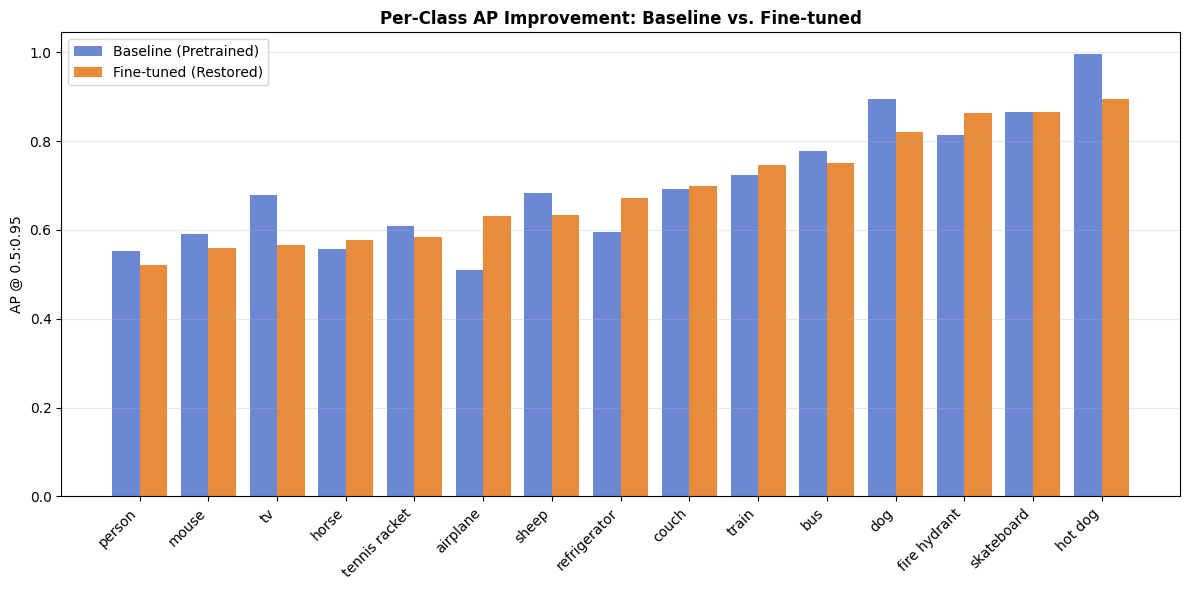


image 1/100 /kaggle/working/outputs/task4/dataset/images/val/000000002299.jpg: 416x640 27 persons, 6 ties, 55.2ms
image 2/100 /kaggle/working/outputs/task4/dataset/images/val/000000009400.jpg: 480x640 11 persons, 2 bottles, 5 cups, 1 tv, 7 laptops, 2 mouses, 1 keyboard, 52.9ms
image 3/100 /kaggle/working/outputs/task4/dataset/images/val/000000025603.jpg: 480x640 6 persons, 3 cups, 1 pizza, 16 chairs, 2 dining tables, 1 book, 1 clock, 27.6ms
image 4/100 /kaggle/working/outputs/task4/dataset/images/val/000000037740.jpg: 480x640 2 chairs, 1 couch, 1 potted plant, 1 tv, 1 laptop, 1 mouse, 1 keyboard, 1 book, 1 clock, 21.3ms
image 5/100 /kaggle/working/outputs/task4/dataset/images/val/000000039484.jpg: 448x640 10 persons, 12 cars, 1 airplane, 1 traffic light, 3 chairs, 52.9ms
image 6/100 /kaggle/working/outputs/task4/dataset/images/val/000000052996.jpg: 448x640 8 persons, 3 bottles, 3 cups, 1 knife, 4 bowls, 1 dining table, 1 refrigerator, 20.9ms
image 7/100 /kaggle/working/outputs/task4/d

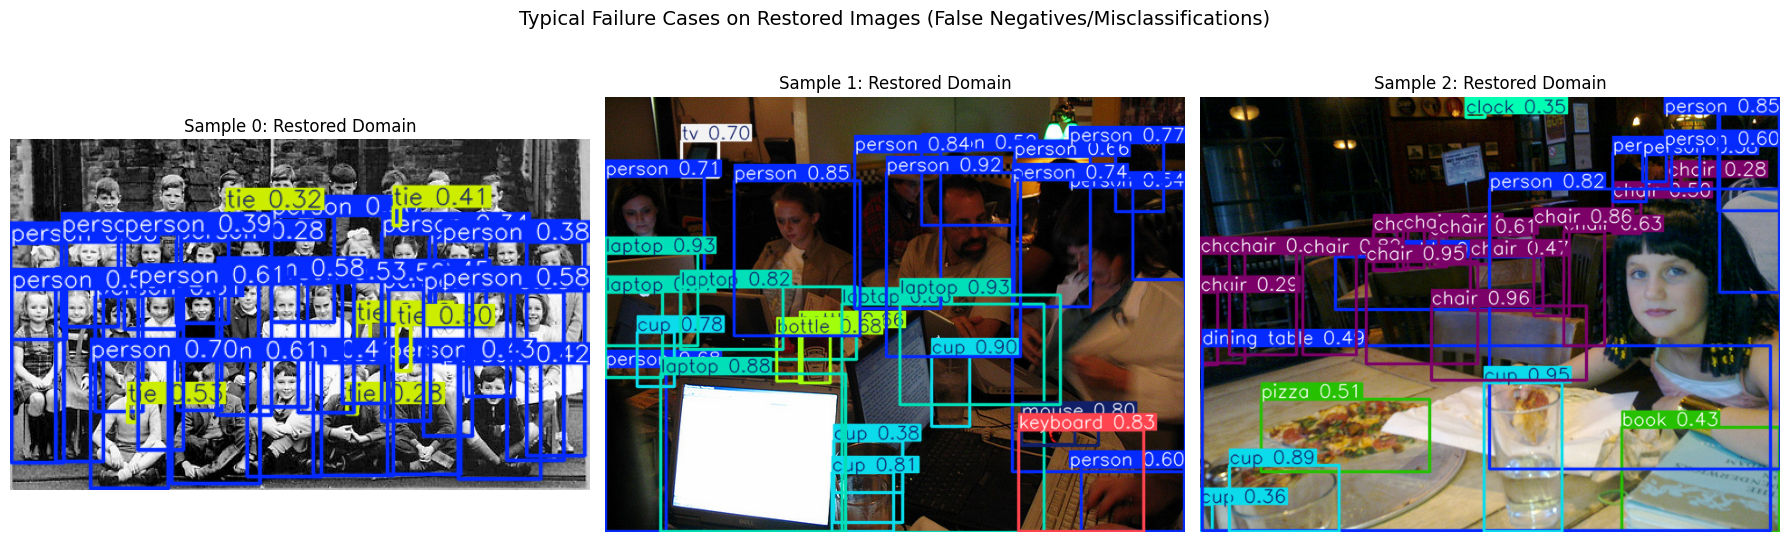

In [14]:
# ============================================================
# Task 5: Performance Comparison and Critical Analysis
# COMP6001 Assignment 1
# ============================================================

import os
from pathlib import Path
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tqdm import tqdm

# ── 1. Paths ─────────────────────────────────────────────────
TASK4_DIR  = Path("/kaggle/working/outputs/task4")
YAML_PATH  = TASK4_DIR / "dataset/data.yaml"
# Best model from Task 4
FINETUNED_WEIGHTS = TASK4_DIR / "runs/nafnet_deblur/weights/best.pt"
# Baseline model
BASELINE_WEIGHTS  = "yolov8m.pt"

OUTPUT_DIR = Path("/kaggle/working/outputs/task5")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 2. Comparison Function ───────────────────────────────────

def run_comprehensive_eval():
    print("Loading models...")
    model_ft = YOLO(FINETUNED_WEIGHTS)
    model_bs = YOLO(BASELINE_WEIGHTS)
    
    # We evaluate on the validation set created in Task 4
    # Domain A: Blurred (Input to pipeline)
    # Domain B: Restored (NAFNet Output)
    # Domain C: Sharp (Ground Truth Reference)
    
    results_data = []

    print("\n[1/2] Evaluating Baseline Model (yolov8m.pt)...")
    res_bs = model_bs.val(data=str(YAML_PATH), imgsz=640, split='val', verbose=False)
    
    print("\n[2/2] Evaluating Fine-tuned Model (Task 4 Best)...")
    res_ft = model_ft.val(data=str(YAML_PATH), imgsz=640, split='val', verbose=False)

    # ── 3. Statistical Summary Table ────────────────────────── 
    
    metrics = {
        "Metric": ["mAP50", "mAP50-95", "Precision", "Recall", "Fitness"],
        "Baseline": [
            res_bs.box.map50, res_bs.box.map, 
            res_bs.box.mp, res_bs.box.mr, res_bs.fitness
        ],
        "Fine-tuned (Restored)": [
            res_ft.box.map50, res_ft.box.map, 
            res_ft.box.mp, res_ft.box.mr, res_ft.fitness
        ]
    }
    
    df = pd.DataFrame(metrics)
    df["Gain (%)"] = ((df["Fine-tuned (Restored)"] - df["Baseline"]) / df["Baseline"]) * 100
    df.to_csv(OUTPUT_DIR / "performance_comparison.csv", index=False)
    
    print(f"\n{'='*65}")
    print(f"{'STATISTICAL COMPARISON: BASELINE VS RESTORED':^65}")
    print(f"{'='*65}")
    print(df.to_string(index=False))
    print(f"{'='*65}\n")

    # ── 4. Visualizing Per-Class Improvement ────────────────── 
    
    classes = model_ft.names
    bs_ap = res_bs.box.maps  # AP per class
    ft_ap = res_ft.box.maps
    
    # Filter to top 15 classes present in the validation set for clarity
    top_indices = np.argsort(ft_ap)[-15:] 
    
    plt.figure(figsize=(12, 6))
    x = np.arange(len(top_indices))
    plt.bar(x - 0.2, [bs_ap[i] for i in top_indices], 0.4, label='Baseline (Pretrained)', color='#6c88d4')
    plt.bar(x + 0.2, [ft_ap[i] for i in top_indices], 0.4, label='Fine-tuned (Restored)', color='#e88b3a')
    
    plt.xticks(x, [classes[i] for i in top_indices], rotation=45, ha='right')
    plt.ylabel("AP @ 0.5:0.95")
    plt.title("Per-Class AP Improvement: Baseline vs. Fine-tuned", fontweight='bold')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "per_class_ap.png", dpi=150)
    plt.show()

# ── 5. Failure Case Analysis ────────────────────────────────── 

def visualize_failure_cases(model, yaml_path, num_samples=3):
    """Detects and saves images where restoration still fails to yield correct detections."""
    results = model.predict(source=str(TASK4_DIR/"dataset/images/val"), conf=0.25, save=False)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(18, 6))
    fig.suptitle("Typical Failure Cases on Restored Images (False Negatives/Misclassifications)", fontsize=14)
    
    for i in range(num_samples):
        img = results[i].plot() # YOLO annotated image
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Sample {i}: Restored Domain")
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "failure_analysis.png")
    plt.show()

# ── 6. Execution ──────────────────────────────────────────────

if __name__ == "__main__":
    run_comprehensive_eval()
    # Using the fine-tuned model to inspect remaining weaknesses
    visualize_failure_cases(YOLO(FINETUNED_WEIGHTS), YAML_PATH)